In [1]:
import pandas as pd
from pathlib import Path

CLEAN_FILE = Path(
    r"F:\pojects for github\NLP-Based Customer Review & Complaint Analyzer"
    r"\review-analyzer\data\clean\swiggy_reviews_clean_ipynb.csv"
)

df = pd.read_csv(CLEAN_FILE)

print("Dataset loaded successfully.")
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Shape:", df.shape)

Dataset loaded successfully.
Rows: 5000
Columns: 12
Shape: (5000, 12)


In [2]:
# Convert review timestamp to datetime
df["at"] = pd.to_datetime(df["at"], errors="coerce")

# Count reviews per day
daily_reviews = (
    df.set_index("at")
      .resample("D")
      .size()
      .reset_index(name="review_count")
)

print("Daily review volume:")
print(daily_reviews.to_string(index=False))

Daily review volume:
        at  review_count
2026-08-03           183
2026-08-04           467
2026-08-05           416
2026-08-06           384
2026-08-07           404
2026-08-08           465
2026-08-09           598
2026-08-10           411
2026-08-11           376
2026-08-12           447
2026-08-13           407
2026-08-14           442


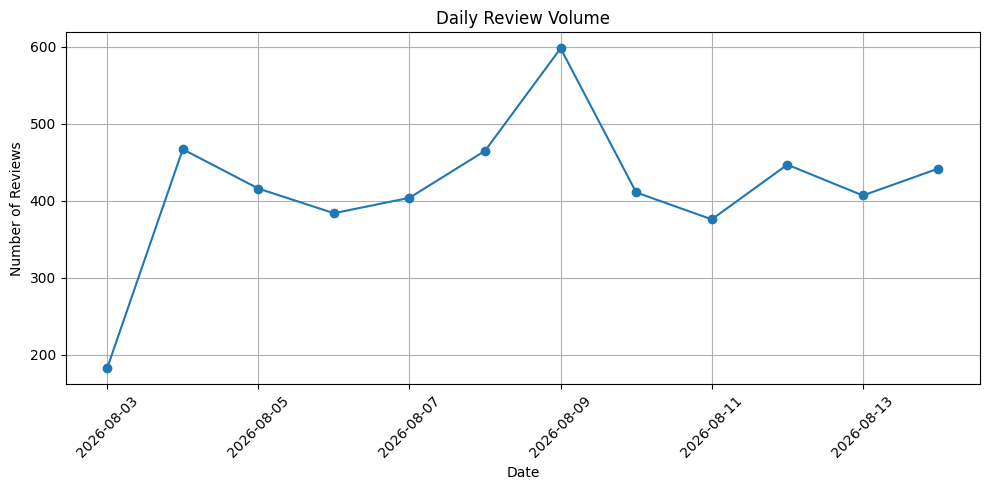

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    daily_reviews["at"],
    daily_reviews["review_count"],
    marker="o"
)

plt.title("Daily Review Volume")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [4]:
rating_counts = df["score"].value_counts().sort_index()

print("Rating distribution:")
print(rating_counts)

Rating distribution:
score
1    1587
2     149
3     213
4     445
5    2606
Name: count, dtype: int64


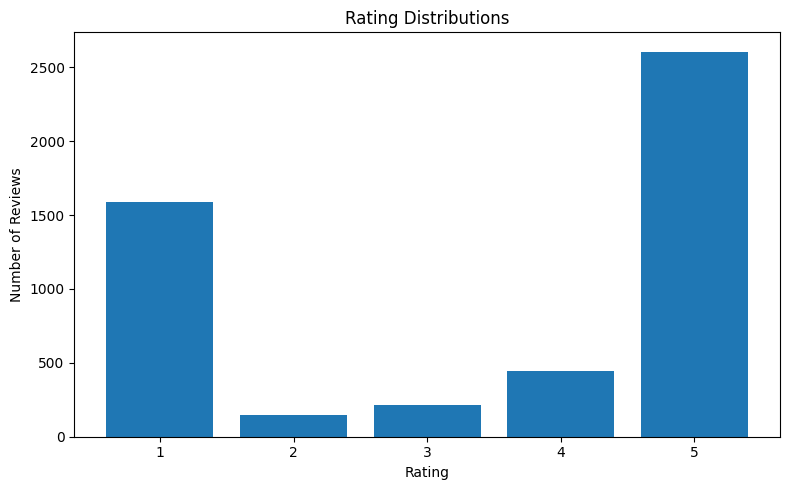

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("Rating Distributions")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

In [8]:
df["review_length"] = df["content"].astype(str).str.len()

print("Review length statistics:")
print(df["review_length"].describe())

Review length statistics:
count    5000.000000
mean       59.574400
std       110.799109
min         1.000000
25%         4.000000
50%        12.000000
75%        49.000000
max       500.000000
Name: review_length, dtype: float64


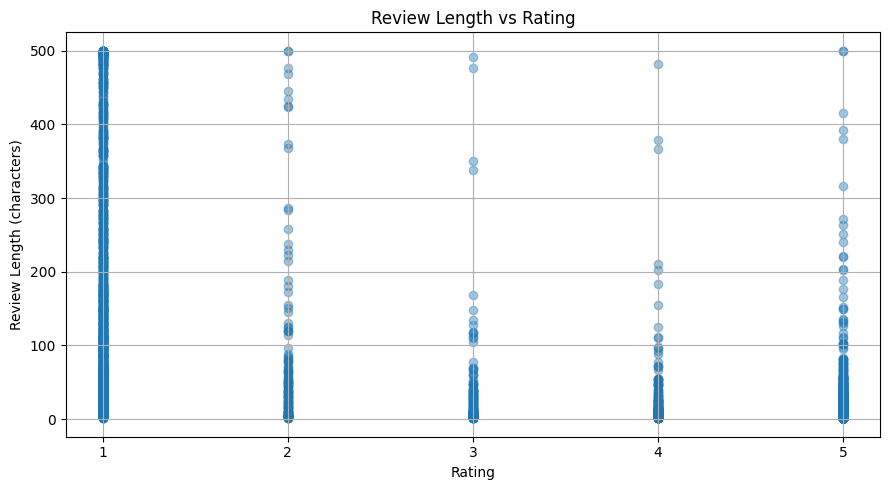

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.scatter(
    df["score"],
    df["review_length"],
    alpha=0.4
)

plt.title("Review Length vs Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (characters)")
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True)
plt.tight_layout()

plt.show()

In [10]:
import nltk

print("NLTK version:", nltk.__version__)

NLTK version: 3.9.1


In [11]:
from nltk.corpus import stopwords

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Keep important negation words
negation_words = {"not", "no", "nor", "never"}

stop_words = stop_words - negation_words

print("Number of stopwords:", len(stop_words))
print("Negation words kept:", sorted(negation_words))

Number of stopwords: 195
Negation words kept: ['never', 'no', 'nor', 'not']


In [14]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["content"].apply(
    lambda text: [
        word for word in word_tokenize(text)
        if word.isalpha() and word not in stop_words
    ]
)

print("Sample tokenized reviews:")
print(df[["content", "tokens"]].head(10).to_string(index=False))

Sample tokenized reviews:
                                                                                                                                                                                                                                                                                                                                                                                                                      content                                                                                                                                                                                                                                                                                                                                                   tokens
                                                                                                                                                                                                                       

In [13]:
import nltk

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\arpit\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [15]:
from collections import Counter

all_words = [
    word
    for tokens in df["tokens"]
    for word in tokens
]

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

print("Top 20 words:")
for word, count in top_words:
    print(f"{word}: {count}")

Top 20 words:
good: 1570
app: 799
order: 789
delivery: 678
swiggy: 662
not: 578
food: 535
service: 501
nice: 473
worst: 405
customer: 401
time: 375
no: 285
experience: 248
support: 245
bad: 225
refund: 200
best: 188
ordered: 179
super: 173


In [16]:
from collections import Counter

bigrams = []

for tokens in df["tokens"]:
    for i in range(len(tokens) - 1):
        bigrams.append((tokens[i], tokens[i + 1]))

bigram_counts = Counter(bigrams)

top_bigrams = bigram_counts.most_common(20)

print("Top 20 bigrams:")
for (word1, word2), count in top_bigrams:
    print(f"{word1} {word2}: {count}")

Top 20 bigrams:
customer support: 121
good service: 103
worst app: 101
customer service: 88
customer care: 82
delivery partner: 77
food delivery: 76
cancel order: 66
good app: 61
worst customer: 51
worst experience: 51
bad experience: 51
ordered food: 44
worst service: 43
delivery app: 41
nice app: 41
delivery time: 39
experience swiggy: 38
app ever: 32
delivery boy: 32


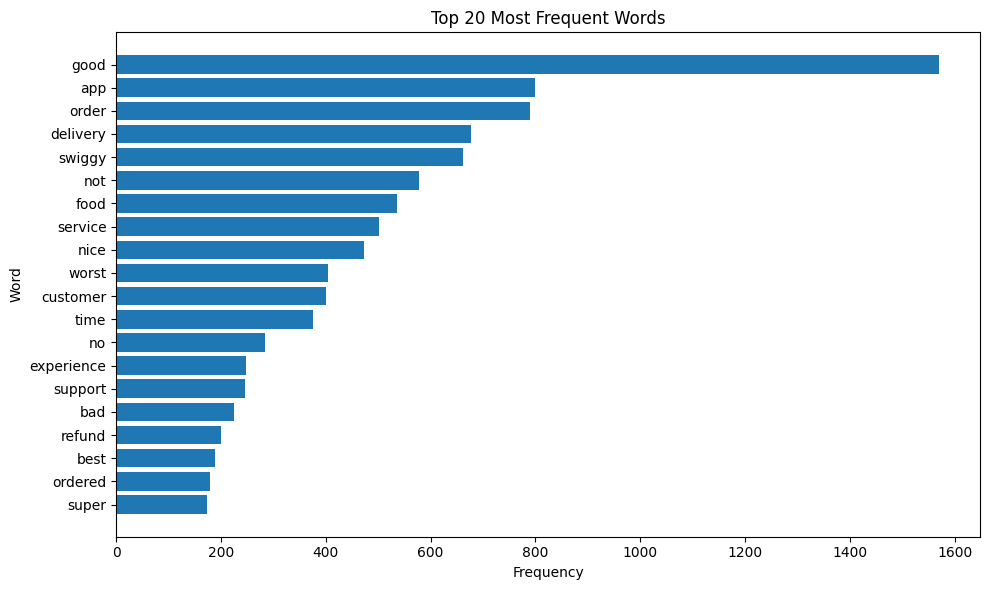

In [17]:
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(10, 6))

plt.barh(words[::-1], counts[::-1])

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

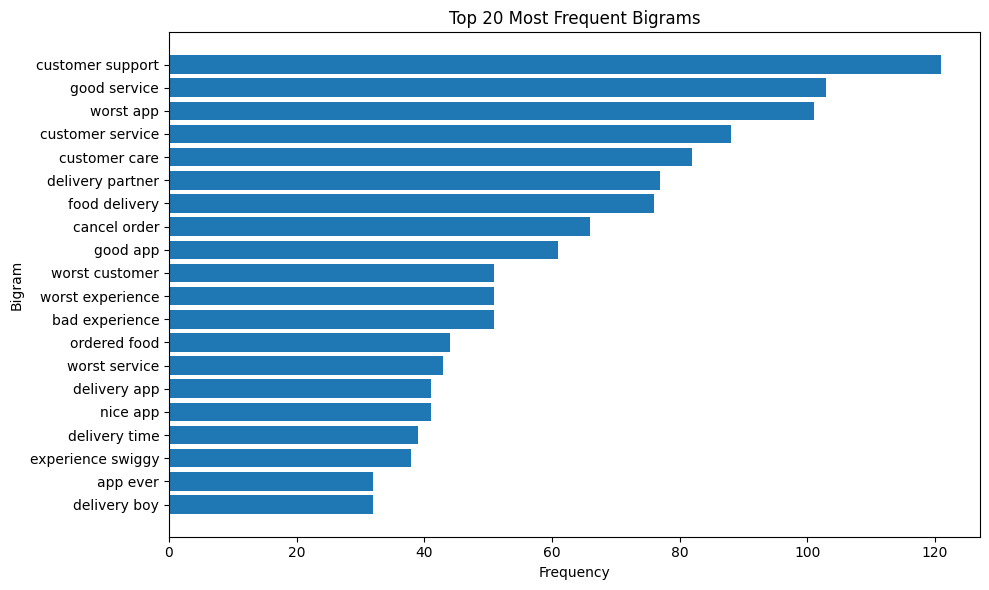

In [18]:
bigram_labels = [
    f"{word1} {word2}"
    for (word1, word2), count in top_bigrams
]

bigram_counts_values = [
    count
    for (word1, word2), count in top_bigrams
]

plt.figure(figsize=(10, 6))

plt.barh(
    bigram_labels[::-1],
    bigram_counts_values[::-1]
)

plt.title("Top 20 Most Frequent Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")

plt.tight_layout()
plt.show()

In [19]:
from pathlib import Path

OUTPUT_DIR = Path(
    r"F:\pojects for github\NLP-Based Customer Review & Complaint Analyzer"
    r"\review-analyzer\data\processed"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save daily review volume
daily_reviews.to_csv(
    OUTPUT_DIR / "daily_review_volume.csv",
    index=False
)

# Save rating distribution
rating_counts.rename("review_count").to_csv(
    OUTPUT_DIR / "rating_distribution.csv"
)

# Save top words
pd.DataFrame(
    top_words,
    columns=["word", "frequency"]
).to_csv(
    OUTPUT_DIR / "top_words.csv",
    index=False
)

# Save top bigrams
pd.DataFrame(
    [
        (f"{word1} {word2}", count)
        for (word1, word2), count in top_bigrams
    ],
    columns=["bigram", "frequency"]
).to_csv(
    OUTPUT_DIR / "top_bigrams.csv",
    index=False
)

print("Phase 3 results saved successfully.")
print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nFiles:")
print("1. daily_review_volume.csv")
print("2. rating_distribution.csv")
print("3. top_words.csv")
print("4. top_bigrams.csv")


Phase 3 results saved successfully.

Output directory:
F:\pojects for github\NLP-Based Customer Review & Complaint Analyzer\review-analyzer\data\processed

Files:
1. daily_review_volume.csv
2. rating_distribution.csv
3. top_words.csv
4. top_bigrams.csv


In [20]:
from pathlib import Path
import pandas as pd

OUTPUT_DIR = Path(
    r"F:\pojects for github\NLP-Based Customer Review & Complaint Analyzer"
    r"\review-analyzer\data\processed"
)

files_to_check = [
    "daily_review_volume.csv",
    "rating_distribution.csv",
    "top_words.csv",
    "top_bigrams.csv"
]

for filename in files_to_check:
    file_path = OUTPUT_DIR / filename

    print(f"\n--- {filename} ---")
    print("Exists:", file_path.exists())

    if file_path.exists():
        temp = pd.read_csv(file_path)
        print("Rows:", len(temp))
        print("Columns:", list(temp.columns))


--- daily_review_volume.csv ---
Exists: True
Rows: 12
Columns: ['at', 'review_count']

--- rating_distribution.csv ---
Exists: True
Rows: 5
Columns: ['score', 'review_count']

--- top_words.csv ---
Exists: True
Rows: 20
Columns: ['word', 'frequency']

--- top_bigrams.csv ---
Exists: True
Rows: 20
Columns: ['bigram', 'frequency']
